Real-World Scenario

You are working as a Data Scientist in an Email Security Company.

Your task is to build an Intelligent Email Analysis System that can:

- Detect spam emails
- Understand sentiment
- Extract important entities
- Predict next words
- Build a chatbot for support

Columns:

- label → spam / ham

- message → text

###**🧠 TASK 1**


Objective

Understand dataset patterns.

Tasks

- Check dataset shape
- Count spam vs ham
- Find average message length
- Plot word frequency

###**🧹 TASK 2 — Text Preprocessing Pipeline**

Build a reusable function that performs:

- Lowercasing
- Tokenization
- Stopword removal
- Punctuation removal
- Lemmatization

Bonus

Create a single pipeline function
    def preprocess(text):
        ...
        return cleaned_text

###**🔢 TASK 3 — Feature Engineering (BoW vs TF-IDF)**

Tasks

Convert text using:
- CountVectorizer (BoW)
- TfidfVectorizer

Compare:

- Feature size
- Sparsity
- Model performance

###**🤖 TASK 4 — Baseline Model**

Build a simple model:

Algorithm: Logistic Regression

Steps
- Train model
- Evaluate accuracy
- Confusion matrix

###**📈 TASK 5 — Model Comparison**

Train multiple models:
- Naive Bayes
- Logistic Regression
- SVM

Compare:
- Accuracy
- Precision
- Recall
- F1-score

###**🧠 TASK 6 — Hyperparameter Tuning**

Use:

GridSearchCV

Tune:
- C (Logistic Regression)
- kernel (SVM)


###**📊 TASK 7 — Advanced Feature Engineering**

Implement:
- N-grams (bigram, trigram)

Compare performance:
- ngram_range=(1,2)
- ngram_range=(1,3)


###**🧩 TASK 8 — Word Embeddings (Word2Vec)**

Tasks
- Train Word2Vec model
- Convert sentences → vectors (average embeddings)
- Train classifier
####**😊 TASK 9 — Sentiment Analysis**

Add new feature:
- Sentiment score using TextBlob or VADER
- Combine with TF-IDF.


###**🏷️ TASK 10 — Named Entity Recognition (NER)**

Extract entities from messages:
- Names
- Organizations
- Locations

Use:
- spaCy
###**🔤 TASK 11 — Part-of-Speech Analysis**


Tasks

- Extract POS tags
- Find most common verbs/nouns in spam
###**🔮 TASK 12 — Language Model (N-gram)**

Build:

Bigram model to predict next word.

Example:
  "win money now" → predict next word


In [ ]:
# Install all required libraries
!pip install numpy pandas matplotlib seaborn scikit-learn nltk spacy gensim textblob

# Download spacy model
!python -m spacy download en_core_web_sm

# Download nltk data
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('vader_lexicon')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 86.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Advanced
from sklearn.model_selection import GridSearchCV
from gensim.models import Word2Vec
from nltk.sentiment import SentimentIntensityAnalyzer

# NER
import spacy
nlp = spacy.load("en_core_web_sm")

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Load dataset
df = pd.read_csv('/content/drive/MyDrive/ColabNotebooks/DataSets/spam_email.csv', encoding='latin1')

# Rename columns and drop unnecessary ones
df = df.rename(columns={'v1': 'label', 'v2': 'message'})
df = df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'])

df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


#**TASK-1 : EDA**

(5572, 2)
Index(['label', 'message'], dtype='object')
label
ham     4825
spam     747
Name: count, dtype: int64


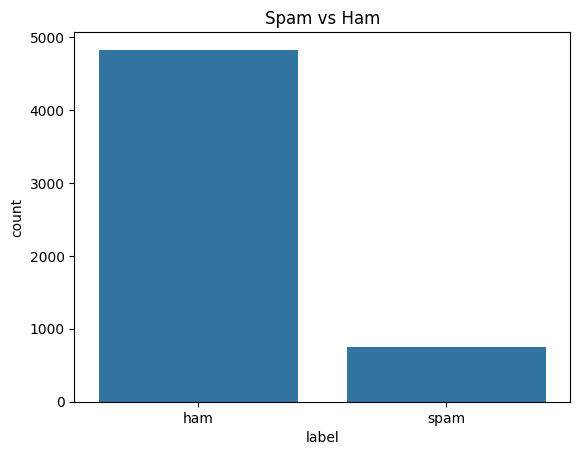

80.11880832735105
[('to', 2134), ('you', 1622), ('I', 1466), ('a', 1327), ('the', 1197), ('and', 857), ('in', 798), ('is', 781), ('i', 742), ('u', 692), ('for', 644), ('my', 628), ('of', 591), ('your', 560), ('me', 557), ('on', 487), ('have', 474), ('2', 453), ('that', 421), ('it', 396)]


In [ ]:

# Shape of dataset
print(df.shape)

# Columns
print(df.columns)

# Count labels
print(df['label'].value_counts())

# Plot
sns.countplot(x=df['label'])
plt.title("Spam vs Ham")
plt.show()


# Add length column
df['length'] = df['message'].apply(len)

# Average length
print(df['length'].mean())


# Combine all text
text = " ".join(df['message'])

# Split words
words = text.split()

# Frequency
from collections import Counter
freq = Counter(words)

# Top 20 words
print(freq.most_common(20))

#**TASK-2 Preprocessing**

In [ ]:

import nltk
nltk.download('punkt_tab', quiet=True) # Download the missing resource

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^ء-ي٠-٩۰-۹،؛؟ـً-ْ۔ەپچژگکۀیےۓۖ-۝۟۠-ۤۧ-۪ۨ-ۭ۰-۹\w\s]', '', text)

    tokens = nltk.word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return " ".join(tokens)

# Apply
df['clean_text'] = df['message'].apply(preprocess)

df.head()

,label,message,length,clean_text
0,ham,"Go until jurong point, crazy.. Available only ...",111,go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,29,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,free entry 2 wkly comp win fa cup final tkts 2...
3,ham,U dun say so early hor... U c already then say...,49,u dun say early hor u c already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,nah dont think go usf life around though


#**TASK 3 — BoW vs TF-IDF**

In [ ]:
# BoW
bow = CountVectorizer()
X_bow = bow.fit_transform(df['clean_text'])

# TF-IDF
tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(df['clean_text'])

print("BoW shape:", X_bow.shape)
print("TF-IDF shape:", X_tfidf.shape)

BoW shape: (5572, 8869)
TF-IDF shape: (5572, 8869)


#**TASK 4 — BASE MODEL**

In [ ]:
# Labels
y = df['label'].map({'ham':0, 'spam':1})

# Split
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2)

# Model
model = LogisticRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9434977578475336
[[959   4]
 [ 59  93]]


#**TASK 5 — MODEL COMPARISON**

In [ ]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(),
    "SVM": SVC()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, pred))
    print(classification_report(y_test, pred))


Naive Bayes
Accuracy: 0.9524663677130045
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       963
           1       1.00      0.65      0.79       152

    accuracy                           0.95      1115
   macro avg       0.97      0.83      0.88      1115
weighted avg       0.95      0.95      0.95      1115


Logistic Regression
Accuracy: 0.9434977578475336
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       963
           1       0.96      0.61      0.75       152

    accuracy                           0.94      1115
   macro avg       0.95      0.80      0.86      1115
weighted avg       0.94      0.94      0.94      1115


SVM
Accuracy: 0.9668161434977578
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       963
           1       0.98      0.77      0.86       152

    accuracy                           0.97      1115
  

#**TASK 6 — HYPERPARAMETER TUNING**

In [ ]:
param_grid = {'C':[0.1,1,10]}

grid = GridSearchCV(LogisticRegression(), param_grid, cv=3)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'C': 10}


#**TASK 7 — N-GRAMS**

In [ ]:
tfidf_bigram = TfidfVectorizer(ngram_range=(1,2))
X_bigram = tfidf_bigram.fit_transform(df['clean_text'])

print(X_bigram.shape)

(5572, 40492)


#**TASK 8 — WORD2VEC**

In [ ]:
sentences = [text.split() for text in df['clean_text']]

w2v = Word2Vec(sentences, vector_size=100, window=5, min_count=1)

# Sentence vector
def sent_vector(sentence):
    words = sentence.split()
    word_vectors = [w2v.wv[word] for word in words if word in w2v.wv]
    if len(word_vectors) == 0:

        return np.zeros(w2v.vector_size)
    else:
        return np.mean(word_vectors, axis=0)

X_w2v = np.array([sent_vector(text) for text in df['clean_text']])

#**TASK 9 — SENTIMENT**

In [ ]:
sia = SentimentIntensityAnalyzer()

df['sentiment'] = df['clean_text'].apply(lambda x: sia.polarity_scores(x)['compound'])

df.head()

,label,message,length,clean_text,sentiment
0,ham,"Go until jurong point, crazy.. Available only ...",111,go jurong point crazy available bugis n great ...,0.4019
1,ham,Ok lar... Joking wif u oni...,29,ok lar joking wif u oni,0.4767
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,free entry 2 wkly comp win fa cup final tkts 2...,0.7964
3,ham,U dun say so early hor... U c already then say...,49,u dun say early hor u c already say,0.0000
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,nah dont think go usf life around though,-0.1027


#**TASK 10 — NER**

In [ ]:
def get_entities(text):
    doc = nlp(text)
    return [(ent.text, ent.label_) for ent in doc.ents]

df['entities'] = df['message'].apply(get_entities)

df[['message','entities']].head()

,message,entities
0,"Go until jurong point, crazy.. Available only ...","[(Cine, PERSON)]"
1,Ok lar... Joking wif u oni...,[]
2,Free entry in 2 a wkly comp to win FA Cup fina...,"[(2, CARDINAL), (FA Cup, EVENT), (21st May 200..."
3,U dun say so early hor... U c already then say...,"[(U dun, PRODUCT)]"
4,"Nah I don't think he goes to usf, he lives aro...",[]


#**TASK 11 — POS TAGGING**

In [ ]:
import nltk
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

def pos_tags(text):
    return nltk.pos_tag(nltk.word_tokenize(text))

df['pos'] = df['clean_text'].apply(pos_tags)

df.head()

,label,message,length,clean_text,sentiment,entities,pos
0,ham,"Go until jurong point, crazy.. Available only ...",111,go jurong point crazy available bugis n great ...,0.4019,"[(Cine, PERSON)]","[(go, VB), (jurong, JJ), (point, NN), (crazy, ..."
1,ham,Ok lar... Joking wif u oni...,29,ok lar joking wif u oni,0.4767,[],"[(ok, JJ), (lar, JJ), (joking, NN), (wif, NN),..."
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,free entry 2 wkly comp win fa cup final tkts 2...,0.7964,"[(2, CARDINAL), (FA Cup, EVENT), (21st May 200...","[(free, JJ), (entry, NN), (2, CD), (wkly, JJ),..."
3,ham,U dun say so early hor... U c already then say...,49,u dun say early hor u c already say,0.0000,"[(U dun, PRODUCT)]","[(u, JJ), (dun, NNS), (say, VBP), (early, JJ),..."
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,nah dont think go usf life around though,-0.1027,[],"[(nah, JJ), (dont, NN), (think, VBP), (go, VB)..."


#**TASK 12 — BIGRAM LANGUAGE MODEL**

In [ ]:
from nltk.util import bigrams
from collections import defaultdict

model = defaultdict(lambda: defaultdict(int))

for sentence in df['clean_text']:
    tokens = sentence.split()
    for w1, w2 in bigrams(tokens):
        model[w1][w2] += 1

# Predict next word
def predict_next(word):
    return max(model[word], key=model[word].get)

print(predict_next("win"))

å100
